# k-NN Classification - sklearn in Action

> **MLCourse · Machine Learning · supervised · classification**

k-Nearest Neighbors never trains: prediction = vote of the k closest rows.
Real data: sklearn's bundled **wine** set (178 wines, 13 chemical features,
3 grape cultivars).

### What you'll learn
- Pipeline(scaler + KNN) end-to-end
- Why scaling changes EVERYTHING for distance models (visual proof)
- Choosing k by cross-validation curve
- Decision-boundary picture on two features

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

wine = load_wine(as_frame=True)
X, y = wine.data, wine.target
print(X.shape, "| classes:", wine.target_names)
display(X.describe().T[["mean", "std"]].round(2).head(6))   # scales differ wildly!

(178, 13) | classes: ['class_0' 'class_1' 'class_2']


,mean,std
alcohol,13.00,0.81
malic_acid,2.34,1.12
ash,2.37,0.27
alcalinity_of_ash,19.49,3.34
magnesium,99.74,14.28
total_phenols,2.30,0.63


### 1. Scaling proof - same model, with and without StandardScaler


In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

raw = KNeighborsClassifier().fit(X_tr, y_tr)
scaled_pipe = Pipeline([("sc", StandardScaler()),
                        ("knn", KNeighborsClassifier())]).fit(X_tr, y_tr)

print(f"accuracy WITHOUT scaler : {raw.score(X_te, y_te):.3f}")
print(f"accuracy WITH scaler    : {scaled_pipe.score(X_te, y_te):.3f}")
print("→ 'proline' (range ~1000s) dominated raw distances and drowned 12 features")

pd.DataFrame(confusion_matrix(y_te, scaled_pipe.predict(X_te)),
             index=wine.target_names, columns=wine.target_names)

accuracy WITHOUT scaler : 0.778
accuracy WITH scaler    : 0.933
→ 'proline' (range ~1000s) dominated raw distances and drowned 12 features


,class_0,class_1,class_2
class_0,15,0,0
class_1,0,16,2
class_2,0,1,11


### 2. Choosing k with cross-validation


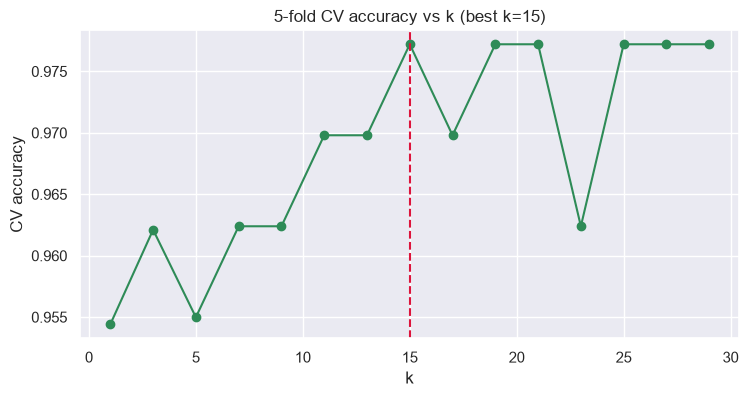

test accuracy with k=15: 1.000


In [3]:
cv_means = []
k_values = list(range(1, 31, 2))
for k in k_values:
    m = Pipeline([("sc", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))])
    cv_means.append(cross_val_score(m, X_tr, y_tr, cv=5).mean())

plt.figure(figsize=(8.5, 4))
plt.plot(k_values, cv_means, "o-", color="seagreen")
best_k = k_values[int(np.argmax(cv_means))]
plt.axvline(best_k, ls="--", c="crimson")
plt.title(f"5-fold CV accuracy vs k (best k={best_k})")
plt.xlabel("k"); plt.ylabel("CV accuracy"); plt.show()

final = Pipeline([("sc", StandardScaler()),
                  ("knn", KNeighborsClassifier(n_neighbors=best_k))]) \
                .fit(X_tr, y_tr)
print(f"test accuracy with k={best_k}: {final.score(X_te, y_te):.3f}")

### 3. Seeing the boundary - two features only


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


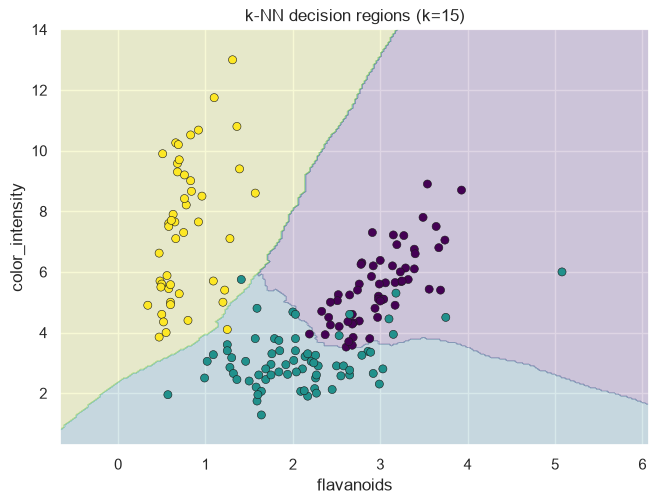

In [4]:
two = ["flavanoids", "color_intensity"]
p2 = Pipeline([("sc", StandardScaler()),
               ("knn", KNeighborsClassifier(n_neighbors=best_k))]) \
              .fit(X_tr[two], y_tr)

gx = np.linspace(X[two[0]].min()-1, X[two[0]].max()+1, 250)
gy = np.linspace(X[two[1]].min()-1, X[two[1]].max()+1, 250)
Gxx, Gyy = np.meshgrid(gx, gy)
zz = p2.predict(np.c_[Gxx.ravel(), Gyy.ravel()]).reshape(Gxx.shape)

plt.figure(figsize=(7.6, 5.4))
plt.contourf(Gxx, Gyy, zz, alpha=.18, cmap="viridis")
plt.scatter(X[two[0]], X[two[1]], c=y, cmap="viridis", edgecolor="k", lw=.4, s=34)
plt.xlabel(two[0]); plt.ylabel(two[1])
plt.title(f"k-NN decision regions (k={best_k})")
plt.show()
# Patchy islands near ambiguous points = classic k-NN texture.

### Summary & key takeaways

- k-NN = lazy learner: zero fit, all work at predict time.
- Scale or die - one wide-range feature hijacks every distance.
- Pick k by CV curve: small k jaggy/overfit, huge k lazy-majority.
- Boundaries are piecewise patches around neighborhoods - intuitive but costly
  at scale (each prediction scans the whole dataset).